# Exploratory Data Analysis (EDA)

## Objective
Explore the cleaned student mental health dataset, identify relationships with depression, and derive insights for feature engineering, model training, wellness scoring, and recommendations.

# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the cleaned student mental health dataset and identify relationships between different factors and depression.

The insights obtained from this analysis will be used for:

- Feature Engineering
- Wellness Score Design
- Model Training
- Recommendation Generation

In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [70]:
clean_df = pd.read_csv(r"D:\Project\Mental-Health-Analyzer-New\ml\data\processed\cleaned_kaggle.csv")

clean_df.head()

,Gender,Age,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33,5,8.97,2,'5-6 hours',Healthy,B.Pharm,Yes,3,1,No,1
1,Female,24,2,5.90,5,'5-6 hours',Moderate,BSc,No,3,2,Yes,0
2,Male,31,3,7.03,5,'Less than 5 hours',Healthy,BA,No,9,1,Yes,0
3,Female,28,3,5.59,2,'7-8 hours',Moderate,BCA,Yes,4,5,Yes,1
4,Female,25,4,8.13,3,'5-6 hours',Moderate,M.Tech,Yes,1,1,No,0


In [71]:
print("Shape :", clean_df.shape)

Shape : (27812, 13)


In [72]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27812 entries, 0 to 27811
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27812 non-null  str    
 1   Age                                    27812 non-null  int64  
 2   Academic Pressure                      27812 non-null  int64  
 3   CGPA                                   27812 non-null  float64
 4   Study Satisfaction                     27812 non-null  int64  
 5   Sleep Duration                         27812 non-null  str    
 6   Dietary Habits                         27812 non-null  str    
 7   Degree                                 27812 non-null  str    
 8   Have you ever had suicidal thoughts ?  27812 non-null  str    
 9   Work/Study Hours                       27812 non-null  int64  
 10  Financial Stress                       27812 non-null  int64  
 11  Family Histor

In [73]:
clean_df.describe()

,Age,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27812.000000,27812.000000,27812.000000,27812.000000,27812.000000,27812.000000,27812.000000
mean,25.795628,3.142456,7.658569,2.944341,7.160255,3.139508,0.586150
std,4.861796,1.380291,1.466187,1.360272,3.706283,1.437424,0.492531
min,18.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,2.000000,6.290000,2.000000,4.000000,2.000000,0.000000
50%,25.000000,3.000000,7.770000,3.000000,8.000000,3.000000,1.000000
75%,30.000000,4.000000,8.920000,4.000000,10.000000,4.000000,1.000000
max,34.000000,5.000000,10.000000,5.000000,12.000000,5.000000,1.000000


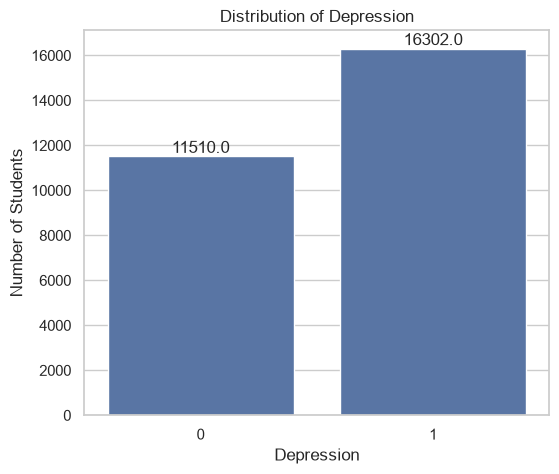

In [74]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="Depression",
    data=clean_df
)

plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Number of Students")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

In [75]:
clean_df["Depression"].value_counts(normalize=True)*100

Depression
1    58.614986
0    41.385014
Name: proportion, dtype: float64

The target variable shows a moderately balanced distribution with approximately 59% of students belonging to the depressed class and 41% belonging to the non-depressed class. Since the imbalance is not severe, standard classification algorithms can be applied while evaluating metrics such as precision, recall, F1-score, and ROC-AUC.

In [76]:
numerical_features = [
    "Age",
    "CGPA",
    "Academic Pressure",
    "Study Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

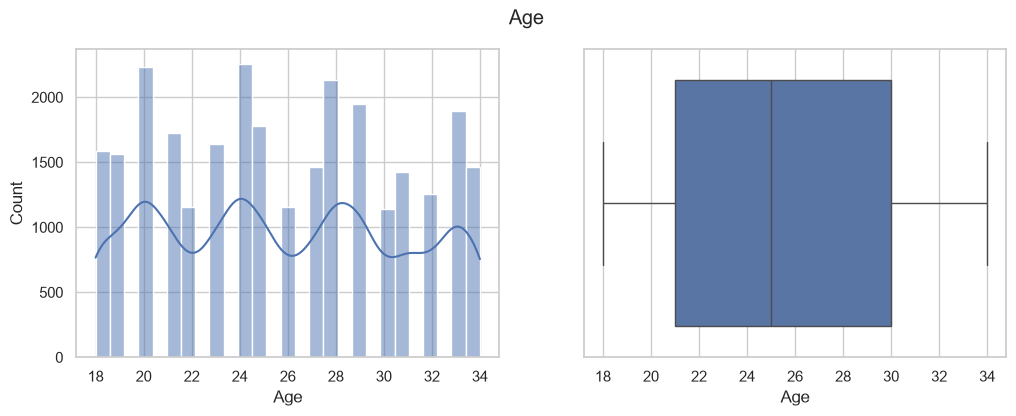

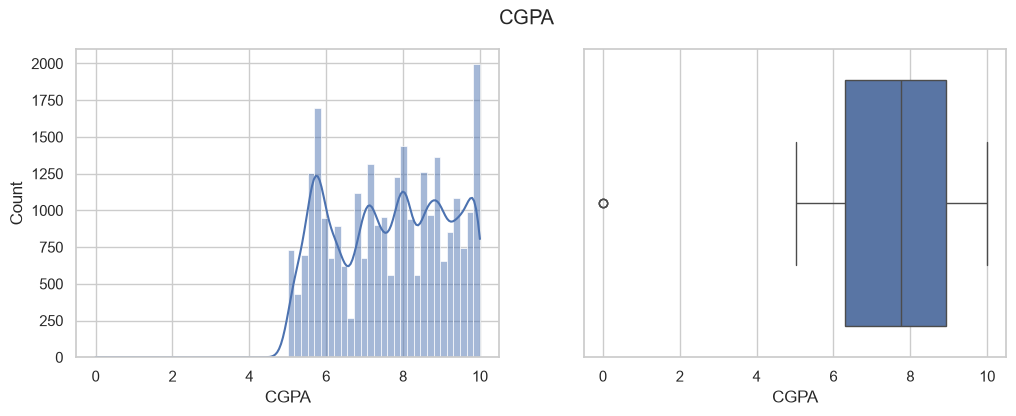

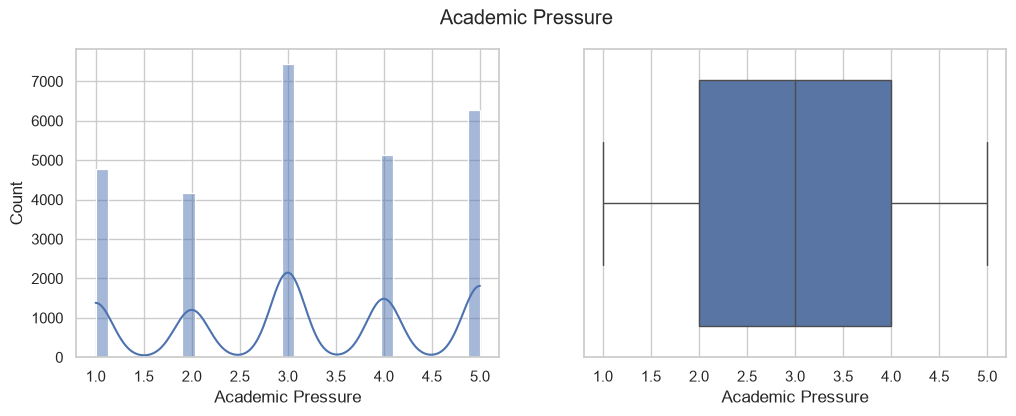

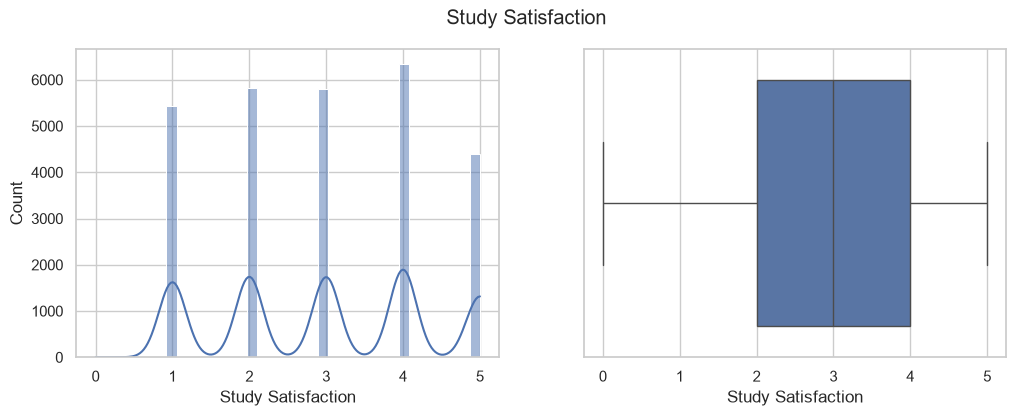

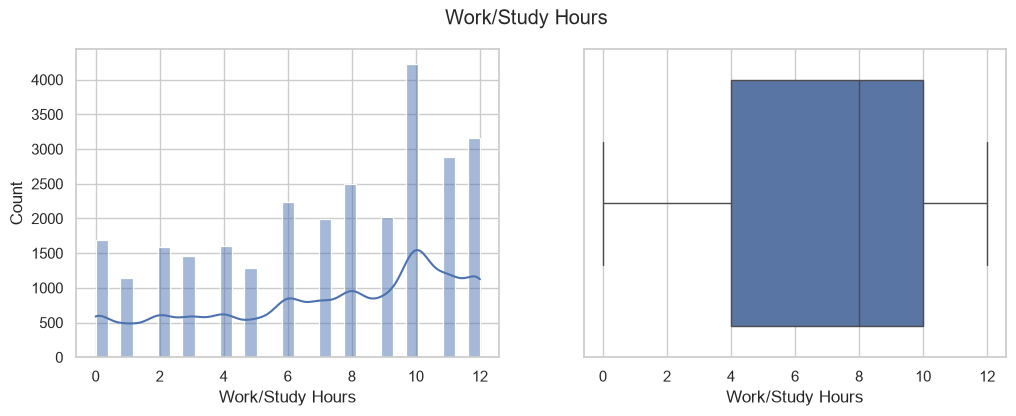

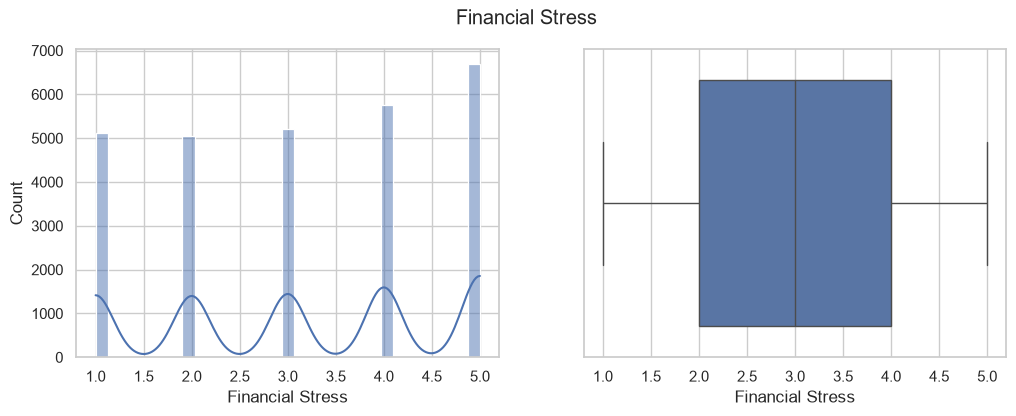

In [77]:
for col in numerical_features:

    fig, axes = plt.subplots(1,2,figsize=(12,4))

    sns.histplot(clean_df[col], kde=True, ax=axes[0])

    sns.boxplot(
        x=clean_df[col],
        ax=axes[1]
    )

    plt.suptitle(col)

    plt.show()

In [78]:
categorical_features = [

    "Gender",

    "Sleep Duration",

    "Dietary Habits",

    "Degree",

    "Have you ever had suicidal thoughts ?",

    "Family History of Mental Illness"

]

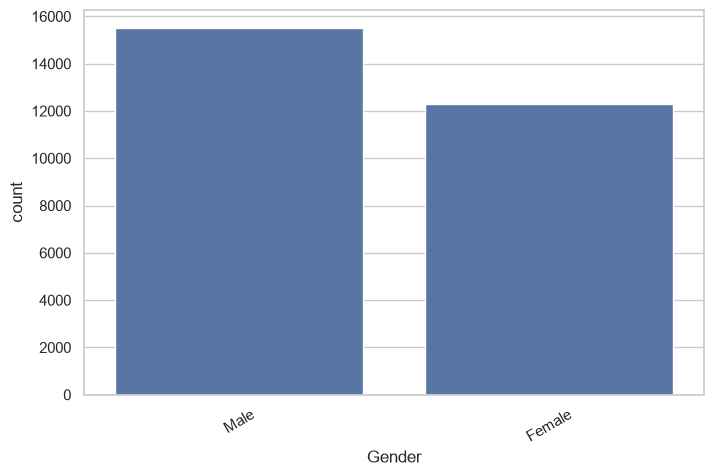

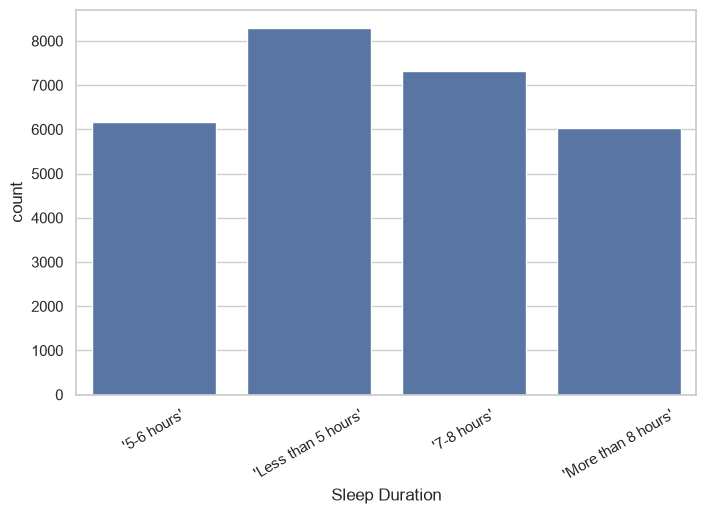

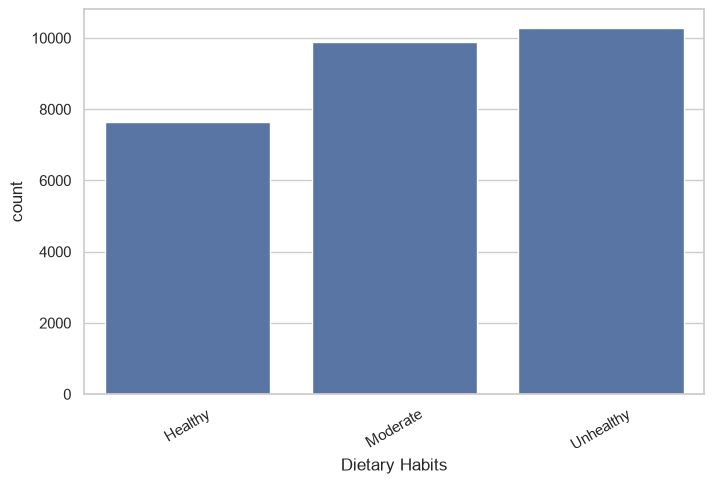

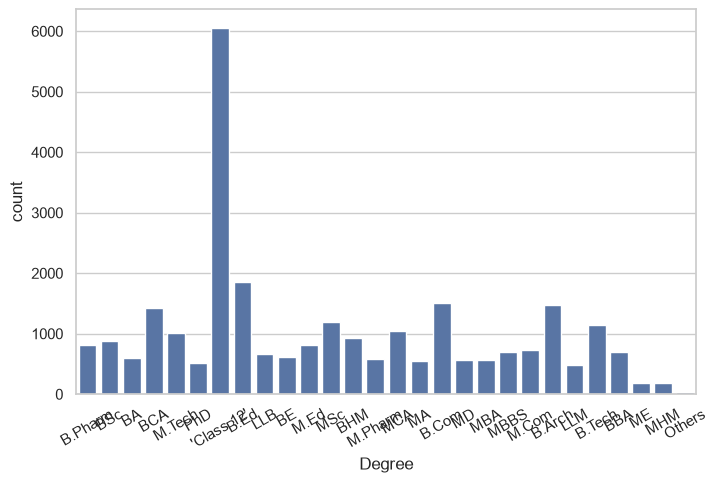

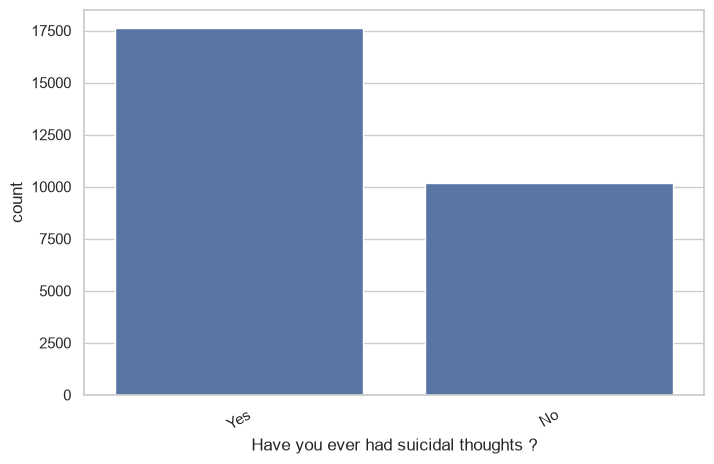

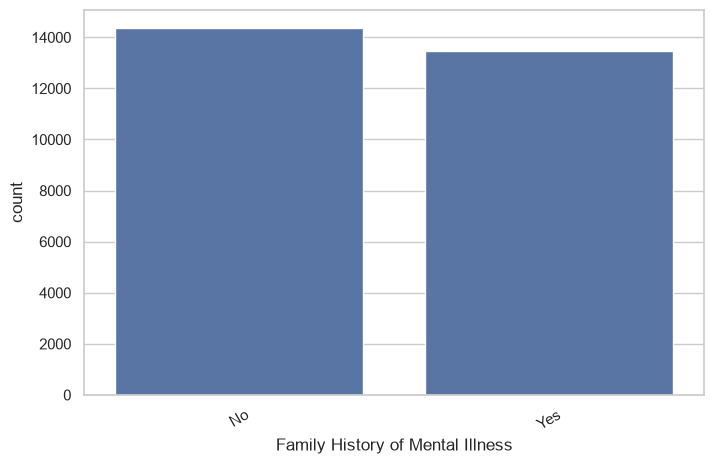

In [79]:
for col in categorical_features:
    plt.figure(figsize=(8,5))

    sns.countplot(
        x=clean_df[col]
    )

    plt.xticks(rotation=30)

    plt.show()

In [80]:
features = [

    "Gender",

    "Sleep Duration",

    "Dietary Habits",

    "Degree",

    "Have you ever had suicidal thoughts ?",

    "Family History of Mental Illness",

    "Age",

    "CGPA",

    "Academic Pressure",

    "Study Satisfaction",

    "Work/Study Hours",

    "Financial Stress"

]

In [81]:
def plot_feature_vs_depression(df, feature):
    """
    Displays the percentage of depressed and non-depressed students
    for each category of a feature.
    """

    # Percentage table
    percentage_table = (
        pd.crosstab(
            df[feature],
            df["Depression"],
            normalize="index"
        ) * 100
    ).round(2)

    print(f"\n{'='*70}")
    print(f"{feature}")
    print(f"{'='*70}")
    display(percentage_table)

    # Plot
    percentage_table.plot(
        kind="bar",
        stacked=True,
        figsize=(10,5)
    )

    plt.title(f"{feature} vs Depression (%)")
    plt.xlabel(feature)
    plt.ylabel("Percentage of Students")
    plt.xticks(rotation=30)
    plt.legend(["Not Depressed", "Depressed"], title="Depression")
    plt.tight_layout()
    plt.show()


Gender


Depression,0,1
Gender,,
Female,41.46,58.54
Male,41.33,58.67


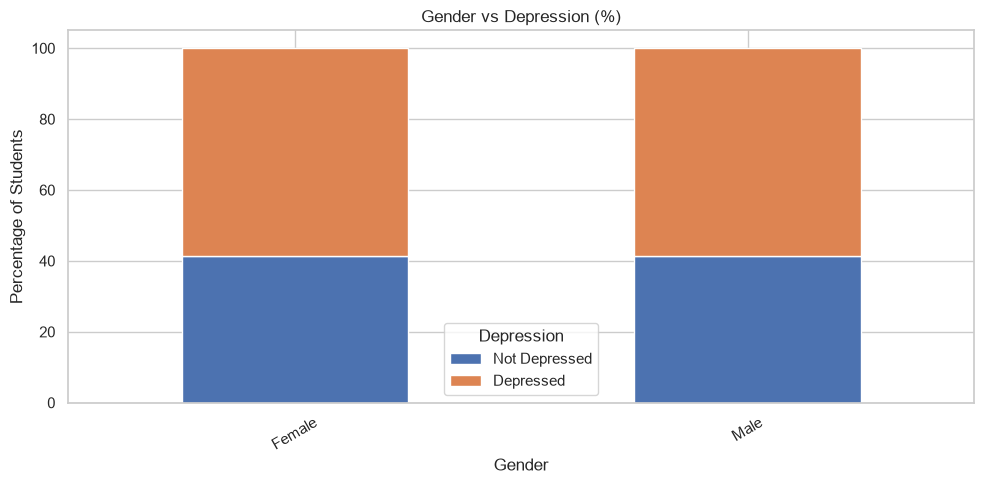


Sleep Duration


Depression,0,1
Sleep Duration,,
'5-6 hours',43.04,56.96
'7-8 hours',40.44,59.56
'Less than 5 hours',35.43,64.57
'More than 8 hours',49.02,50.98


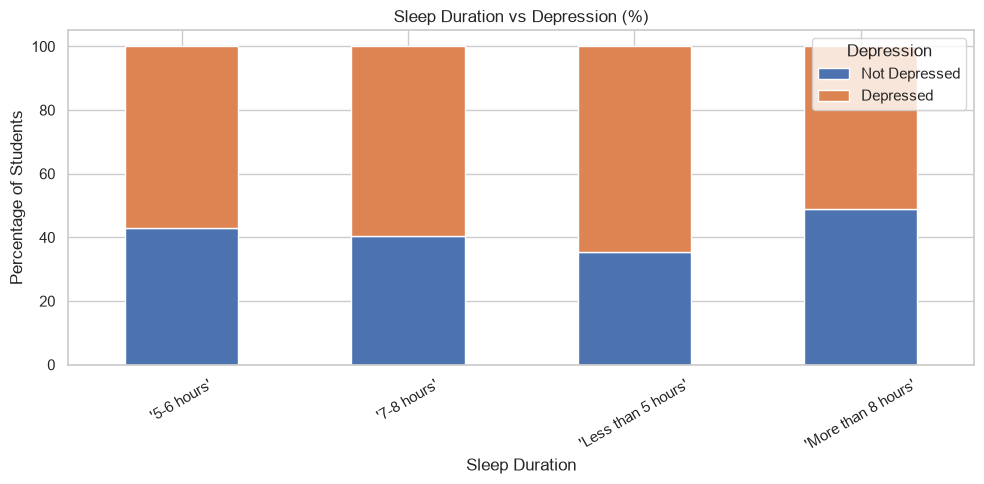


Dietary Habits


Depression,0,1
Dietary Habits,,
Healthy,54.59,45.41
Moderate,43.89,56.11
Unhealthy,29.19,70.81


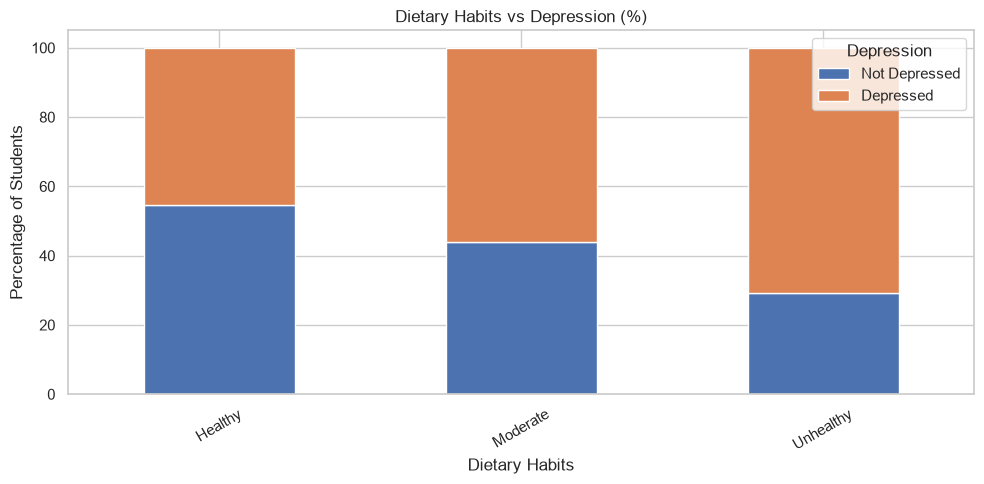


Degree


Depression,0,1
Degree,,
'Class 12',29.12,70.88
B.Arch,40.98,59.02
B.Com,43.30,56.70
B.Ed,45.27,54.73
B.Pharm,47.10,52.90
B.Tech,43.18,56.82
BA,46.57,53.43
BBA,41.52,58.48
BCA,42.84,57.16


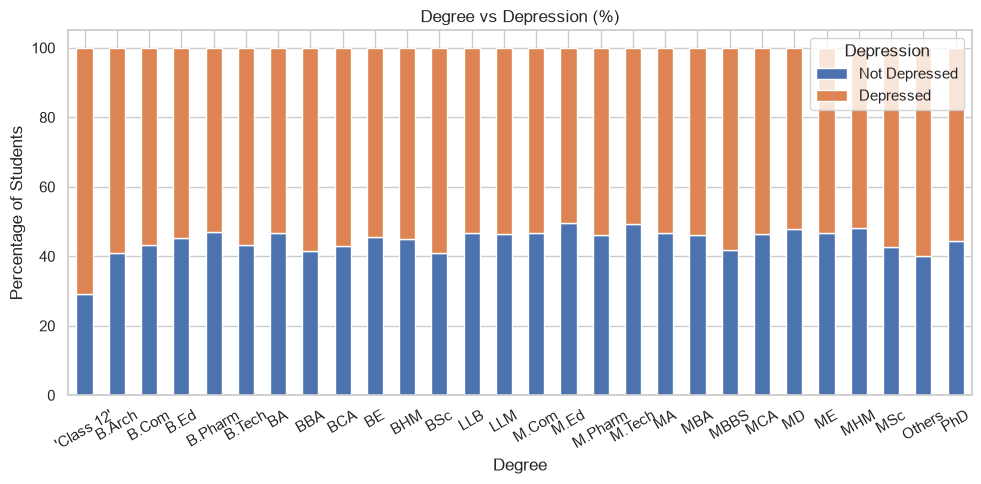


Have you ever had suicidal thoughts ?


Depression,0,1
Have you ever had suicidal thoughts ?,,
No,76.76,23.24
Yes,20.89,79.11


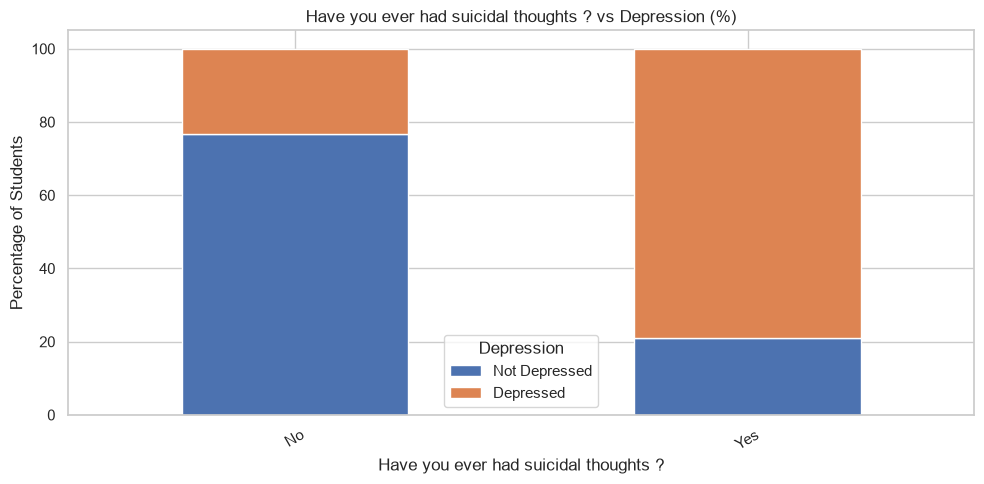


Family History of Mental Illness


Depression,0,1
Family History of Mental Illness,,
No,43.94,56.06
Yes,38.66,61.34


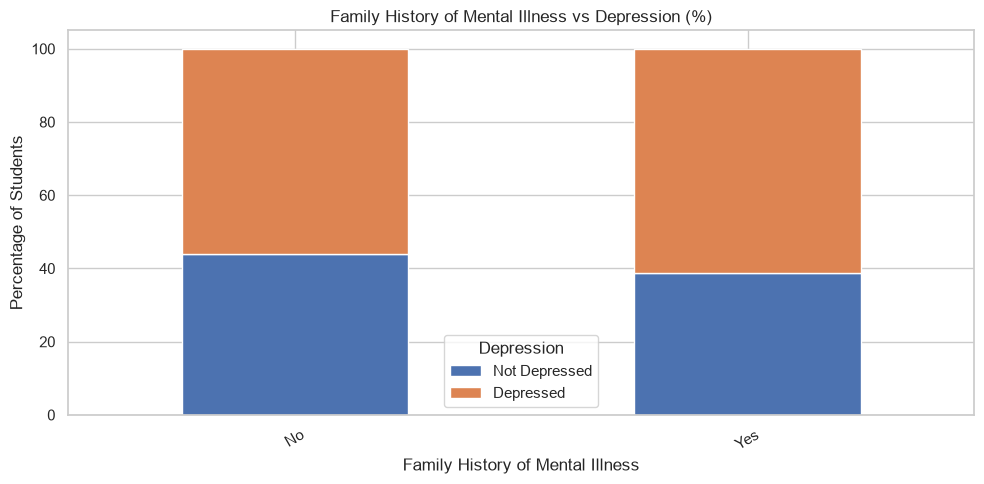


Age


Depression,0,1
Age,,
18,23.37,76.63
19,29.49,70.51
20,29.33,70.67
21,32.19,67.81
22,39.60,60.40
23,36.14,63.86
24,33.16,66.84
25,39.34,60.66
26,42.50,57.50


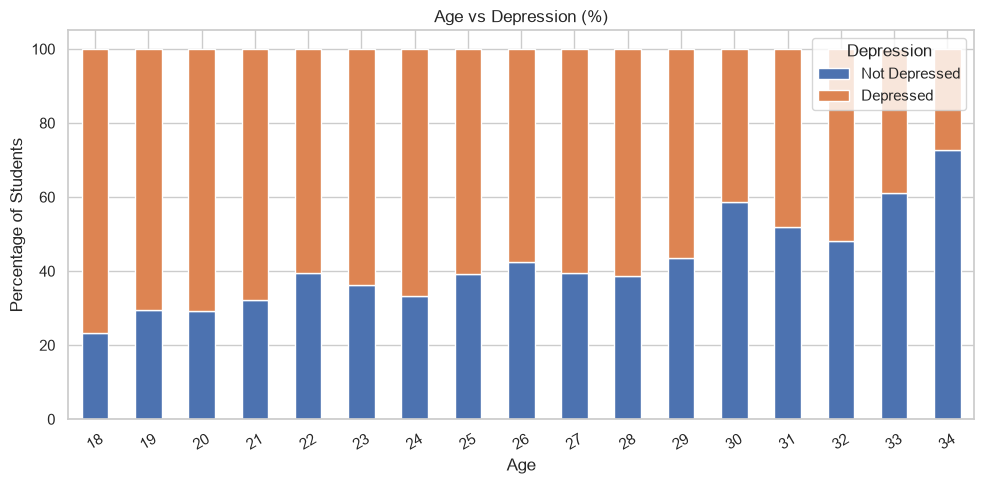


CGPA


Depression,0,1
CGPA,,
0.00,66.67,33.33
5.03,47.06,52.94
5.06,46.67,53.33
5.08,44.68,55.32
5.09,50.00,50.00
...,...,...
9.95,45.86,54.14
9.96,35.46,64.54
9.97,48.20,51.80


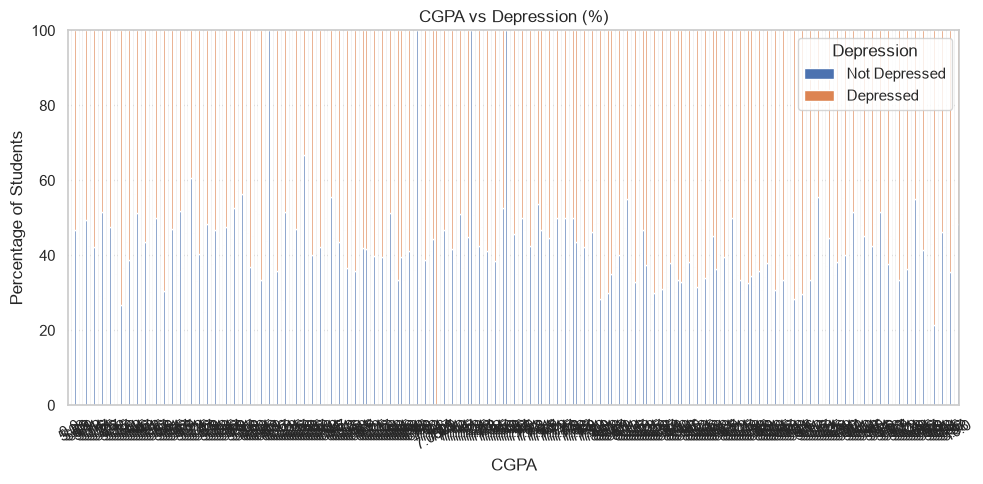


Academic Pressure


Depression,0,1
Academic Pressure,,
1,80.54,19.46
2,62.48,37.52
3,39.77,60.23
4,23.81,76.19
5,13.85,86.15


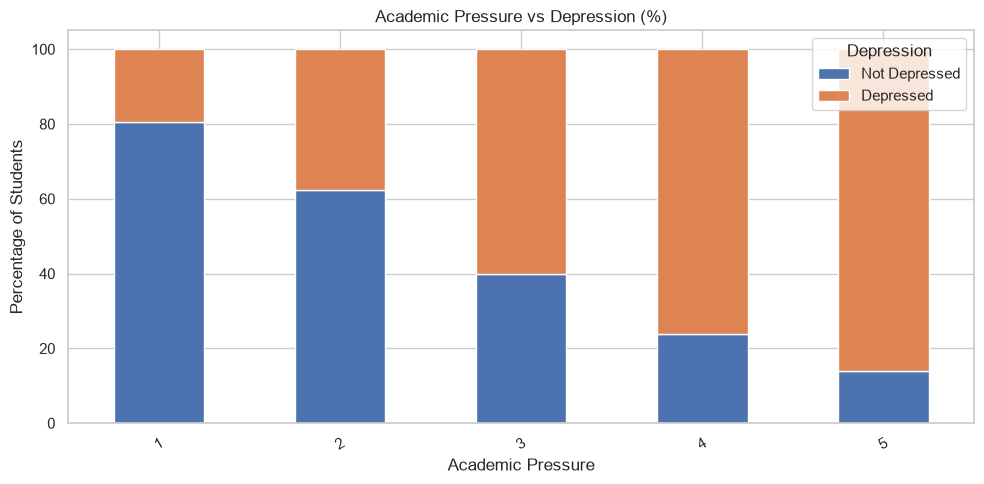


Study Satisfaction


Depression,0,1
Study Satisfaction,,
0,0.00,100.00
1,29.17,70.83
2,35.40,64.60
3,42.30,57.70
4,48.66,51.34
5,52.71,47.29


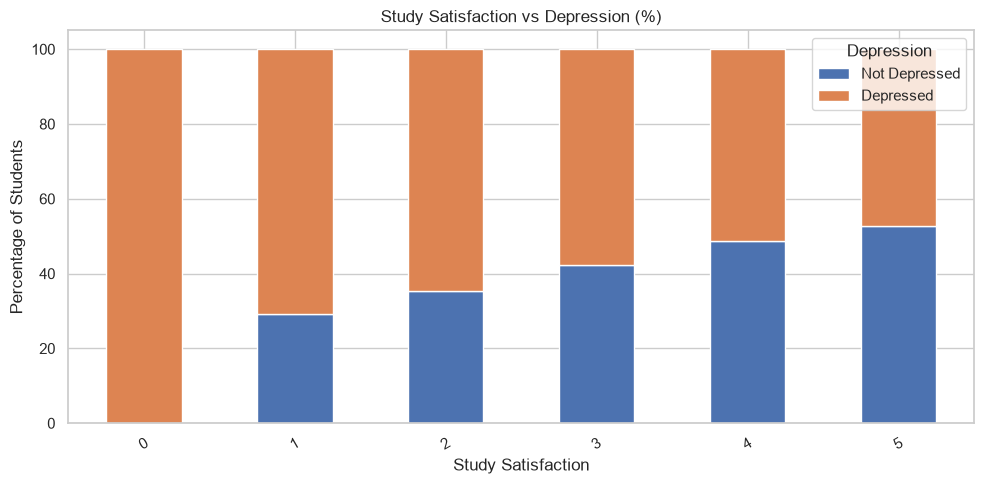


Work/Study Hours


Depression,0,1
Work/Study Hours,,
0,64.36,35.64
1,59.62,40.38
2,56.01,43.99
3,52.46,47.54
4,49.50,50.50
5,45.36,54.64
6,42.62,57.38
7,41.23,58.77
8,37.54,62.46


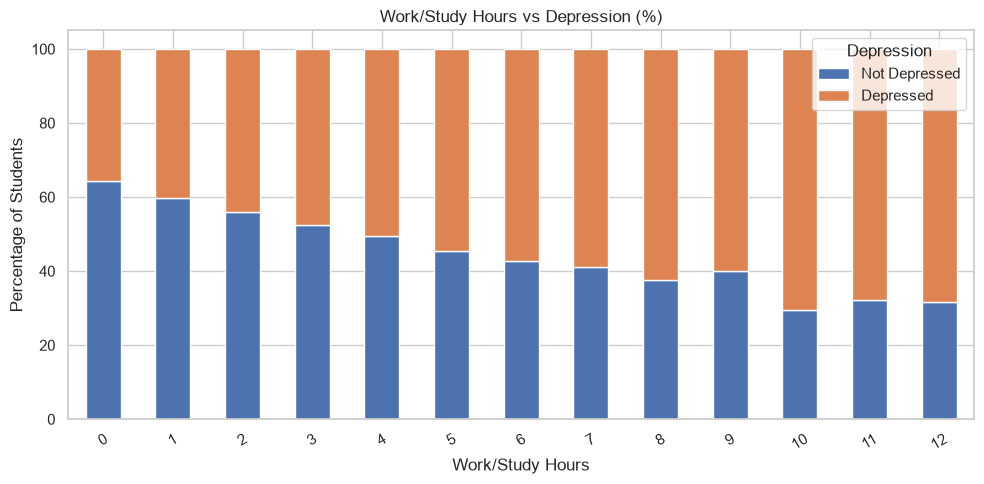


Financial Stress


Depression,0,1
Financial Stress,,
1,68.12,31.88
2,56.96,43.04
3,40.99,59.01
4,30.78,69.22
5,18.66,81.34


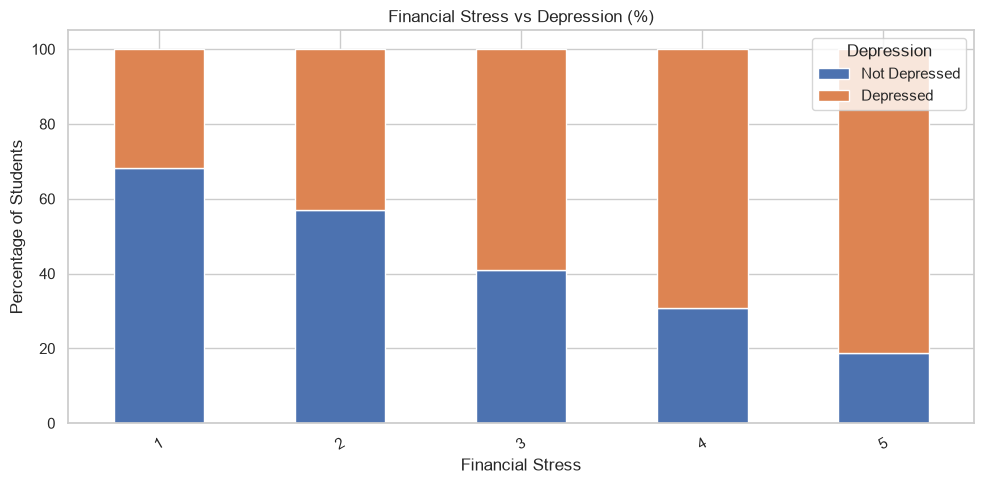

In [82]:
for x in features:
    plot_feature_vs_depression(clean_df, x)

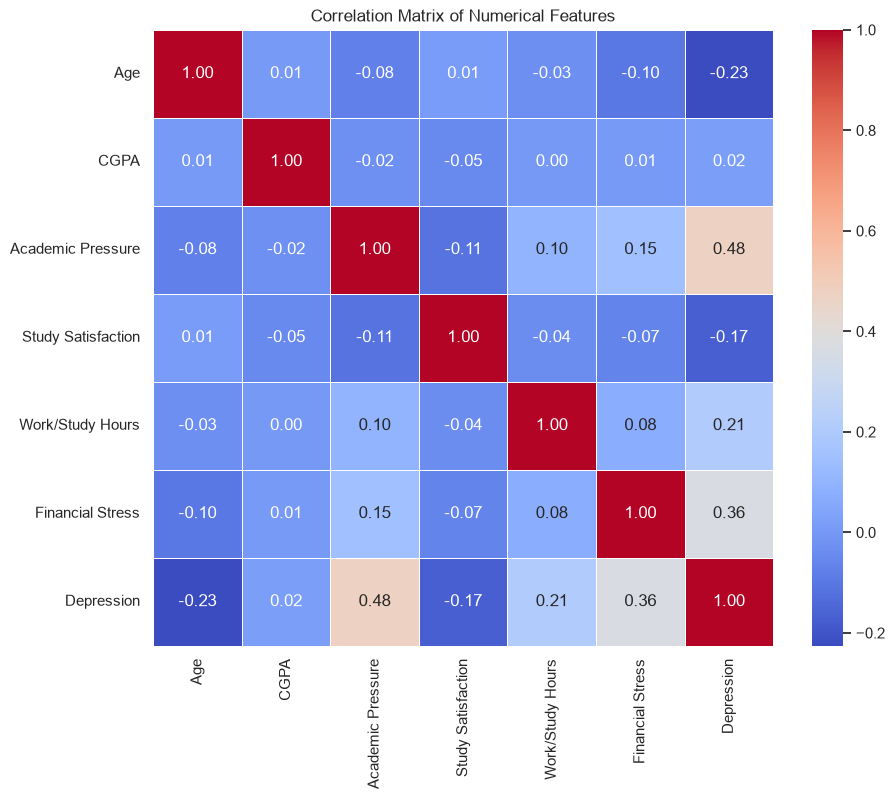

In [83]:
numerical_features = [
    "Age",
    "CGPA",
    "Academic Pressure",
    "Study Satisfaction",
    "Work/Study Hours",
    "Financial Stress",
    "Depression"
]

plt.figure(figsize=(10, 8))

corr = clean_df[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [84]:
corr_with_target = (
    clean_df[numerical_features]
    .corr()["Depression"]
    .sort_values(ascending=False)
)

display(corr_with_target)

Depression            1.000000
Academic Pressure     0.475258
Financial Stress      0.364140
Work/Study Hours      0.207819
CGPA                  0.022216
Study Satisfaction   -0.168448
Age                  -0.225650
Name: Depression, dtype: float64

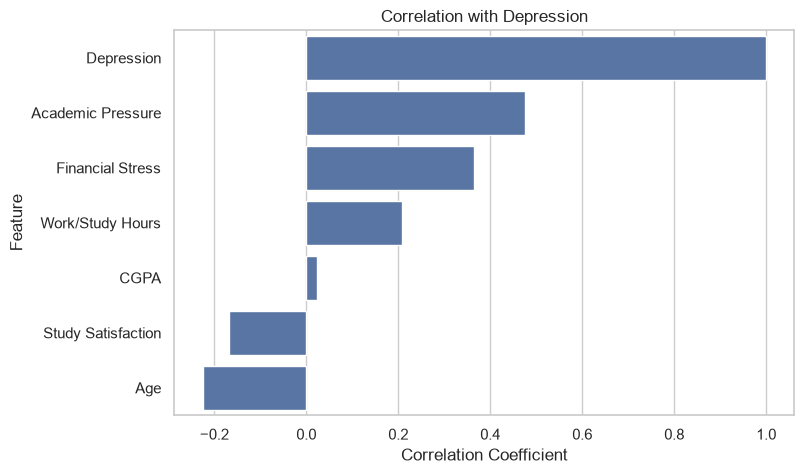

In [85]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index
)

plt.title("Correlation with Depression")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.show()

In [86]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [87]:
categorical_features = [
    "Gender",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]

results = []

for feature in categorical_features:
    score = cramers_v(clean_df[feature], clean_df["Depression"])
    results.append([feature, score])

association_df = (
    pd.DataFrame(results, columns=["Feature", "Cramer's V"])
    .sort_values("Cramer's V", ascending=False)
)

association_df

,Feature,Cramer's V
4,Have you ever had suicidal thoughts ?,0.546570
2,Dietary Habits,0.207961
3,Degree,0.135070
1,Sleep Duration,0.099047
5,Family History of Mental Illness,0.053169
0,Gender,0.000000


## Statistical Testing for Numerical Features

The Mann–Whitney U Test was used to determine whether the distribution of each numerical feature differs significantly between students with and without depression.

Null Hypothesis (H₀):
The distribution of the feature is the same for both groups.

Alternative Hypothesis (H₁):
The distributions are significantly different.

A significance level (α) of 0.05 was used.

In [88]:
from scipy.stats import mannwhitneyu

numerical_features = [
    "Age",
    "CGPA",
    "Academic Pressure",
    "Study Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

results = []

for feature in numerical_features:

    depressed = clean_df[clean_df["Depression"] == 1][feature]
    non_depressed = clean_df[clean_df["Depression"] == 0][feature]

    statistic, p_value = mannwhitneyu(
        depressed,
        non_depressed,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "Statistic": round(statistic,2),
        "P-value": round(p_value,6),
        "Significant": p_value < 0.05
    })

numerical_test = pd.DataFrame(results)

display(numerical_test)

,Feature,Statistic,P-value,Significant
0,Age,69171693.0,0.000000,True
1,CGPA,96220951.0,0.000269,True
2,Academic Pressure,144606127.0,0.000000,True
3,Study Satisfaction,75667335.5,0.000000,True
4,Work/Study Hours,115704722.0,0.000000,True
5,Financial Stress,132937982.5,0.000000,True


## Statistical Testing for Categorical Features

The Chi-Square Test of Independence was used to determine whether each categorical feature is associated with depression.

Null Hypothesis (H₀):
The feature and depression are independent.

Alternative Hypothesis (H₁):
The feature and depression are associated.

A p-value less than 0.05 indicates a statistically significant association.

In [89]:
from scipy.stats import chi2_contingency

categorical_features = [
    "Gender",
    "Sleep Duration",
    "Dietary Habits",
    "Degree",
    "Have you ever had suicidal thoughts ?",
    "Family History of Mental Illness"
]

results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        clean_df[feature],
        clean_df["Depression"]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    results.append({
        "Feature": feature,
        "Chi-Square": round(chi2,2),
        "P-value": round(p_value,6),
        "Significant": p_value < 0.05
    })

categorical_test = pd.DataFrame(results)

display(categorical_test)

,Feature,Chi-Square,P-value,Significant
0,Gender,0.05,0.831888,False
1,Sleep Duration,275.84,0.000000,True
2,Dietary Habits,1204.77,0.000000,True
3,Degree,534.38,0.000000,True
4,Have you ever had suicidal thoughts ?,8309.21,0.000000,True
5,Family History of Mental Illness,79.62,0.000000,True


## Feature Importance Summary
Complete this table based on your statistical tests and visual analysis.

| Feature | Relationship | Significant | Include in Model |
|---|---|---|---|
| Academic Pressure |  | Yes | Yes |
| Study Satisfaction |  | Yes | Yes |
| Financial Stress |  | Yes | Yes |
| Sleep Duration |  | Yes | Yes |
| Dietary Habits |  | Yes | Yes |
| Suicidal Thoughts |  | Yes | Yes |
| Family History |  | Yes | Yes |
| CGPA |  | Yes | Yes |
| Gender |  | No | Review |
| Degree |  | Yes | Review |

## Key Findings
- Summarize the strongest relationships observed in your plots and statistical tests.
- Highlight which features will be prioritized during feature engineering.
- Note that association does not imply causation.

## Conclusion
The EDA identified the variables most strongly associated with depression and established the basis for the next stage: feature engineering and model development.